In [12]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [11]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [3]:
device = 'cuda'

In [4]:
# import os

# # Assumes wget is available! Otherwise, use curl or download manually
# # from https://dspace.mit.edu/handle/1721.1/105492
# os.system("wget https://dspace.mit.edu/bitstream/handle/1721.1/105492/fermi_data.tar.gz?sequence=5");
# os.system("tar -xvf fermi_data.tar.gz?sequence=5");
# os.system("rm -r fermi_data.tar.gz*");

In [5]:
import skimage

In [6]:
n_pixels = 64

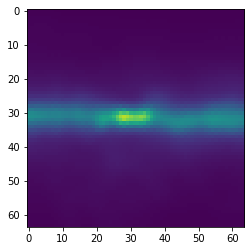

In [7]:
import healpy as hp
from functools import partial

nside= 128

dif_hp = np.load("fermi_data/template_dif.npy")

# Get the cutout via a cartesian projection
lonra = [-10, 10]
latra = [-10, 10]

proj = hp.projector.CartesianProj(lonra=lonra, latra=latra,
    coord='G')

dif_cart = proj.projmap(dif_hp, vec2pix_func=partial(hp.vec2pix, nside))

size = (n_pixels, n_pixels)
dif_cart = skimage.transform.resize(dif_cart, size, order=3)

plt.imshow(dif_cart, vmax=30)

In [8]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.stats import norm

t_min = -1  # Coordinate boundaries
t_max = 1
n_t = n_pixels  # Number of pixels
counts_min = 150  # Minimum and maximum counts emitted by each PS
counts_max = 250
fwhm_psf = 0.1  # FWHM of Gaussian PSF

# Pixel binning
pixel_size = (t_max - t_min) / n_t
bins = np.linspace(t_min, t_max, n_t + 1)

# PSF stuff
sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluctuate=True):
    
    mu_iso = np.random.uniform(10, 20)
    
    mu_ps_iso = np.random.uniform(100, 150)
    n_ps_iso = np.random.poisson(mu_ps_iso)
    
    # Draw position of PSs and their counts
    z_x_iso = np.random.uniform(t_min, t_max, size=(2, n_ps_iso))
    z_c_iso = np.random.uniform(counts_min, counts_max, n_ps_iso)
    
    mu_ps_csp = np.random.uniform(0, 10)
    n_ps_csp = 0  # np.random.poisson(mu_ps_csp)
    
    # Draw position of PSs and their counts
    z_x_csp = norm.rvs(loc=0, scale=0.5, size=(2, n_ps_csp)) 
    z_c_csp = np.random.uniform(counts_min, counts_max, n_ps_csp)
    
    mu_iso_map = mu_iso * np.ones((n_t, n_t))

    if n_ps_iso > 0:
        mu_signal_iso = binned_statistic_2d(x=z_x_iso[0], y=z_x_iso[1], values=z_c_iso, statistic='sum', bins=bins).statistic
    else:
        mu_signal_iso = np.zeros_like(mu_iso_map)
        
    if n_ps_csp > 0:
        mu_signal_csp = binned_statistic_2d(x=z_x_csp[0], y=z_x_csp[1], values=z_c_csp, statistic='sum', bins=bins).statistic
    else:
        mu_signal_csp =  np.zeros_like(mu_iso_map)
        
    counts_binned = (mu_iso_map + 2 * dif_cart + convolve(mu_signal_iso, kernel) + convolve(mu_signal_csp, kernel))

    if poiss_fluctuate:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return mu_ps_iso, counts_binned

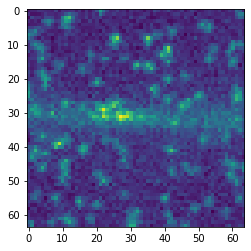

In [9]:
_, _ = simulate(plot=True)

In [50]:
from tqdm.notebook import tqdm
simulations = [simulate() for _ in tqdm(range(30000))]

  0%|          | 0/30000 [00:00<?, ?it/s]

## Glow

In [11]:
import numpy as np
import normflow as nf

In [16]:
# Set up model

# Define flows
L = 3
K = 32
torch.manual_seed(0)

input_shape = (1, n_pixels, n_pixels)
n_dims = np.prod(input_shape)
channels = 1
hidden_channels = 512
split_mode = 'channel'
scale = True

# Set up flows, distributions and merge operations
q0 = []
merges = []
flows = []
for i in range(L):
    flows_ = []
    for j in range(K):
        flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
                                     split_mode=split_mode, scale=scale)]
    flows_ += [nf.flows.Squeeze()]
    flows += [flows_]
    latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i), 
                    input_shape[2] // 2 ** (L - i))
    if i > 0:
        merges += [nf.flows.Merge()]
        latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i), 
                        input_shape[2] // 2 ** (L - i))
    else:
        latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L, 
                        input_shape[2] // 2 ** L)
    q0 += [nf.distributions.DiagGaussian(latent_shape)]


# Construct flow model
model = nf.MultiscaleFlow(q0, flows, merges)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/normflow/flows/mixing.py:77: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at  ../aten/src/ATen/native/BatchLinearAlgebra.cpp:1937.)
  Q = torch.qr(torch.randn(self.num_channels, self.num_channels))[0]


In [17]:
model.class_cond = False

In [18]:
class Glow(pl.LightningModule):

    def __init__(self):
        """
        Inputs:
            flows - A list of flows (each a nn.Module) that should be applied on the images.
        """
        super().__init__()
        self.flows = nf.MultiscaleFlow(q0, flows, merges)
        self.flows.class_cond = False

    def log_prob(self, x):
        """
        Given a batch of images, return the likelihood of those.
        If return_ll is True, this function returns the log likelihood of the input.
        Otherwise, the ouptut metric is bits per dimension (scaled negative log likelihood)
        """
        return self.flows.forward_kld(x)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
        
        return {"optimizer": optimizer, 
                    "lr_scheduler": {
                    "scheduler": scheduler,
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 1}
                }
    def training_step(self, batch, batch_idx):
        # Normalizing flows are trained by maximum likelihood => return bpd
        loss = self.log_prob(batch[0])
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.log_prob(batch[0])
        self.log('val_loss', loss)

In [17]:
x = list(map(itemgetter(1), simulations))

In [18]:
x = torch.Tensor(np.array(x)).unsqueeze(1)#.to(torch.int32)

mu_ps_iso = list(map(itemgetter(0), simulations))
y = torch.Tensor(np.array([mu_ps_iso])).T

x_std = x.std()
x_mean = x.mean()
x = (x - x_mean) / x_std

y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

In [21]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=100, num_workers=8, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=100, num_workers=8, pin_memory=True, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [22]:
model = Glow()

In [24]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
early_stop_callback = EarlyStopping(monitor='val_loss', patience=8)        
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=10, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, early_stop_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
# model.load_from_checkpoint(checkpoint_callback.best_model_path);

In [108]:
cmap = 'RdBu_r'

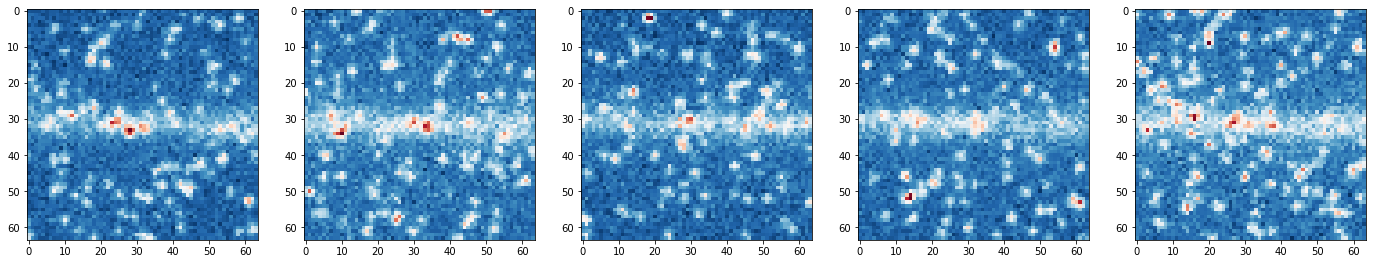

In [116]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5,4 * 1.5))

for ax in axs:
    ax.imshow(model.flows.sample(temperature=1.)[0][0,0].detach().numpy(), cmap=cmap)

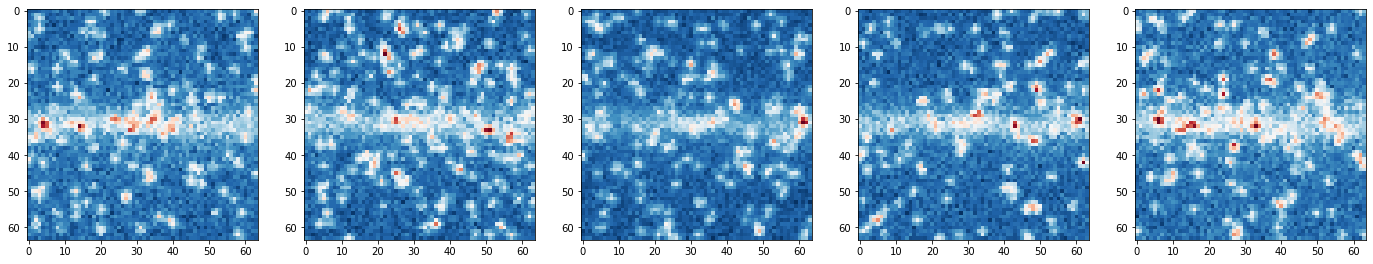

In [117]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy(), cmap=cmap)

In [127]:
x_samples = [model.flows.sample(temperature=1.)[0][0,0].detach().numpy() for _ in tqdm(range(500))]

  0%|          | 0/500 [00:00<?, ?it/s]

In [149]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=2, n_bins=100):
    bins_hist = np.linspace(-counts_max, counts_max, n_bins)
    return np.histogram(x, bins=bins_hist)[0]

In [154]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:1000, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:1000, 0]])

In [140]:
rat = np.nanmean(x_pspec_samples, axis=0)[0] / np.mean(x_pspec_train, axis=0)[0]

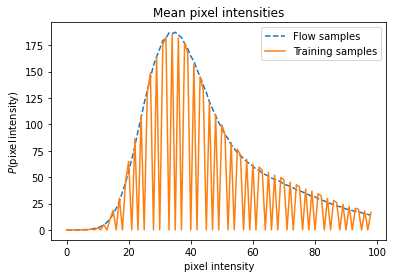

In [160]:
plt.plot(np.nanmean(x_hist_samples, axis=0) * 1.66, label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples")

plt.xlabel("pixel intensity")
plt.ylabel("$P(\mathrm{pixel\,intensity})$")
plt.title("Mean pixel intensities")
         
plt.legend()

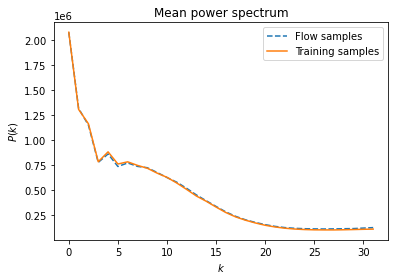

In [161]:
plt.plot(np.nanmean(x_pspec_samples, axis=0) / rat, label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0), label="Training samples")

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title("Mean power spectrum")
         
plt.legend()

In [102]:
def encode(x):
    """
    Get log probability for batch
    :param x: Batch
    :param y: Classes of x
    :return: log probability
    """
    log_q = 0
    z = x
    
    z_list = []
    if model.flows.transform is not None:
        z, log_det = model.flows.transform.inverse(z)
        log_q += log_det
    for i in range(len(model.flows.q0) - 1, -1, -1):
        for j in range(len(model.flows.flows[i]) - 1, -1, -1):
            z, log_det = model.flows.flows[i][j].inverse(z)
            log_q += log_det
        if i > 0:
            [z, z_], log_det = model.flows.merges[i - 1].inverse(z)
            log_q += log_det
        else:
            z_ = z
        z_list.append([z, z_])
    return z_list

def decode(z_list):
    """
    Samples from flow-based approximate distribution
    :param num_samples: Number of samples to draw
    :param y: Classes to sample from, will be sampled uniformly if None
    :param temperature: Temperature parameter for temp annealed sampling
    :return: Samples, log probability
    """
    for i in range(len(model.flows.q0)):
        
        z, z_ = z_list[i]

        if i == 0:
            z = z_
        else:
            z, _ = model.flows.merges[i - 1]([z, z_])
            
        for flow in model.flows.flows[i]:
            z, _ = flow(z)
    if model.flows.transform is not None:
        z, _ = model.flows.transform(z)
    return z

In [169]:
simulations_test = [simulate() for _ in tqdm(range(10))]

x_test = list(map(itemgetter(1), simulations_test))

x_test = torch.Tensor(np.array(x_test)).unsqueeze(1)#.to(torch.int32)
x_test = (x_test - x_mean) / x_std

  0%|          | 0/10 [00:00<?, ?it/s]

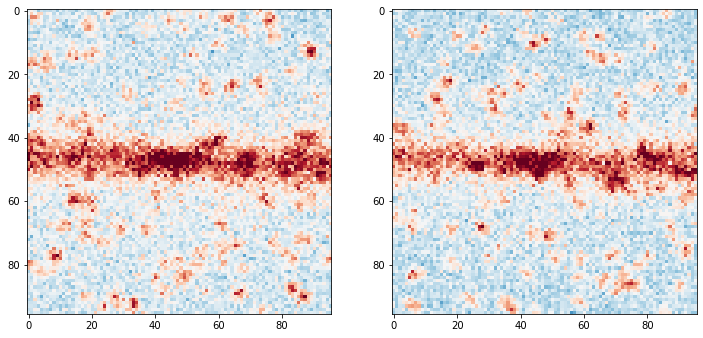

In [193]:
z_list = encode(x_test[:2])
x_dec = decode(z_list[::-1])

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

vrange = 3.2

ax[0].imshow(x_dec[0,0].detach().numpy(), cmap=cmap, vmin=-vrange, vmax=vrange)
ax[1].imshow(x_dec[1,0].detach().numpy(), cmap=cmap, vmin=-vrange, vmax=vrange)

In [194]:
def z_interp(z_list, weight=0.5):
    z_list_interp = []
    for zz_ in z_list:
        z, z_ = zz_
        z = torch.lerp(z[0], z[1], weight).unsqueeze(0)
        z_ = torch.lerp(z_[0], z_[1], weight).unsqueeze(0)
        z_list_interp.append([z, z_])
        
    return z_list_interp

In [195]:
from celluloid import Camera

In [202]:
n_interp = 40

weights_ary = np.linspace(0, 1, n_interp)

fig = plt.figure(figsize=(6,6))

camera = Camera(fig)

for i in range(n_interp):
    z_list_interp = z_interp(z_list, weight=weights_ary[i])
    x_dec = decode(z_list_interp[::-1])
    plt.imshow(x_dec[0,0].detach().numpy(), cmap=cmap, vmin=-vrange, vmax=vrange)
    
    camera.snap()

In [200]:
#Creating the animation from captured frames
animation = camera.animate()

In [201]:
from IPython.display import HTML
HTML(animation.to_html5_video())

In [203]:
animation.save('animation.gif')

## v2

In [51]:
import sys
sys.path.append("../")
sys.path.append("../.")

from models.glow import Glow

In [52]:
model = Glow(256, 3, 16)

In [53]:
from operator import itemgetter

x = list(map(itemgetter(1), simulations))
x = torch.Tensor(x)
x = x.unsqueeze(1)

mu_ps_iso = list(map(itemgetter(0), simulations))
y = torch.Tensor(np.array([mu_ps_iso])).T

### Reversibility test

In [54]:
x[:3]

tensor([[[[59., 38., 22.,  ..., 20., 18., 18.],
          [54., 34., 19.,  ..., 23., 22., 15.],
          [26., 29., 20.,  ..., 24., 20., 16.],
          ...,
          [18., 19., 23.,  ..., 20., 27., 22.],
          [18., 26., 20.,  ..., 27., 41., 29.],
          [19., 25., 16.,  ..., 37., 52., 45.]]],


        [[[15., 16., 10.,  ..., 21., 24., 16.],
          [18., 15., 22.,  ..., 15., 21., 15.],
          [15., 18., 18.,  ..., 17., 16., 20.],
          ...,
          [37., 57., 28.,  ..., 17., 16., 19.],
          [29., 48., 24.,  ..., 16., 15., 14.],
          [22., 29., 23.,  ..., 22., 24., 18.]]],


        [[[56., 43., 26.,  ..., 42., 53., 36.],
          [47., 38., 25.,  ..., 26., 41., 30.],
          [29., 29., 17.,  ..., 24., 19., 26.],
          ...,
          [31., 20., 19.,  ..., 23., 20., 22.],
          [21., 18., 27.,  ..., 31., 13., 19.],
          [21., 28., 13.,  ..., 25., 18., 18.]]]])

In [55]:
z, sldj = model(x[:3])

In [56]:
x_recon, sldj = model(z, reverse=True)

In [57]:
x_recon

tensor([[[[59, 38, 22,  ..., 20, 18, 18],
          [54, 34, 19,  ..., 23, 22, 15],
          [26, 29, 20,  ..., 24, 20, 16],
          ...,
          [18, 19, 23,  ..., 20, 27, 22],
          [18, 26, 20,  ..., 27, 41, 29],
          [19, 25, 16,  ..., 37, 52, 45]]],


        [[[15, 16, 10,  ..., 21, 24, 16],
          [18, 15, 22,  ..., 15, 21, 15],
          [15, 18, 18,  ..., 17, 16, 20],
          ...,
          [37, 57, 28,  ..., 17, 16, 19],
          [29, 48, 24,  ..., 16, 15, 14],
          [22, 29, 23,  ..., 22, 24, 18]]],


        [[[56, 43, 26,  ..., 42, 53, 36],
          [47, 38, 25,  ..., 26, 41, 30],
          [29, 29, 17,  ..., 24, 19, 26],
          ...,
          [31, 20, 19,  ..., 23, 20, 22],
          [21, 18, 27,  ..., 31, 13, 19],
          [21, 28, 13,  ..., 25, 18, 18]]]], dtype=torch.int32)

In [58]:
class NLLLoss(nn.Module):
    """Negative log-likelihood loss assuming isotropic gaussian with unit norm.
    Args:
        k (int or float): Number of discrete values in each input dimension.
            E.g., `k` is 256 for natural images.
    See Also:
        Equation (3) in the RealNVP paper: https://arxiv.org/abs/1605.08803
    """
    def __init__(self, k=256):
        super(NLLLoss, self).__init__()
        self.k = k

    def forward(self, z, sldj):
        prior_ll = -0.5 * (z ** 2 + np.log(2 * np.pi))
        prior_ll = prior_ll.flatten(1).sum(-1) \
            - np.log(self.k) * np.prod(z.size()[1:])
        ll = prior_ll + sldj
        nll = -ll.mean()

        return nll

In [59]:
loss = NLLLoss()

In [60]:
z, sldj = model(x[:3])

nll = loss(z, sldj)

In [61]:
def bits_per_dim(x, nll):
    """Get the bits per dimension implied by using model with `loss`
    for compressing `x`, assuming each entry can take on `k` discrete values.
    Args:
        x (torch.Tensor): Input to the model. Just used for dimensions.
        nll (torch.Tensor): Scalar negative log-likelihood loss tensor.
    Returns:
        bpd (torch.Tensor): Bits per dimension implied if compressing `x`.
    """
    dim = np.prod(x.size()[1:])
    bpd = nll / (np.log(2) * dim)

    return bpd


In [62]:
bits_per_dim(x[:3], nll)

tensor(13.2629, grad_fn=<DivBackward0>)

### Training

In [63]:
class GlowPL(pl.LightningModule):

    def __init__(self):
        """
        Inputs:
            flows - A list of flows (each a nn.Module) that should be applied on the images.
        """
        super().__init__()
        self.flow = Glow(256, 3, 16)
        self.loss = NLLLoss()

    def log_prob(self, x):
        """
        Given a batch of images, return the likelihood of those.
        If return_ll is True, this function returns the log likelihood of the input.
        Otherwise, the ouptut metric is bits per dimension (scaled negative log likelihood)
        """
        
        z, sldj = self.flow(x)
        nll = self.loss(z, sldj)
        bpd = bits_per_dim(x, nll)
        
        return bpd

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
        
        return {"optimizer": optimizer, 
                    "lr_scheduler": {
                    "scheduler": scheduler,
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 1}
                }
    def training_step(self, batch, batch_idx):
        # Normalizing flows are trained by maximum likelihood => return bpd
        loss = self.log_prob(batch[0])
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.log_prob(batch[0])
        self.log('val_loss', loss)

In [64]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=100, num_workers=8, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=100, num_workers=8, pin_memory=True, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [65]:
model = GlowPL()

In [66]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
early_stop_callback = EarlyStopping(monitor='val_loss', patience=8)        
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=25, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, early_stop_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name | Type    | Params
---------------------------------
0 | flow | Glow    | 4.8 M 
1 | loss | NLLLoss | 0     
---------------------------------
4.8 M     Trainable params
0         Non-trainable params
4.8 M     Total params
19.002    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [67]:
cmap = 'RdBu_r'

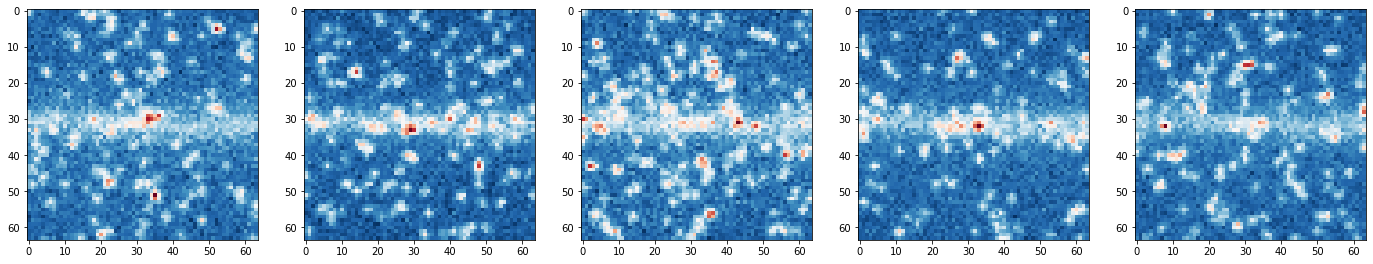

In [68]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy(), cmap=cmap)

In [69]:
z = torch.randn(size=(5, 1, 64,64))
x_samples, sldj = model.flow(z, reverse=True)

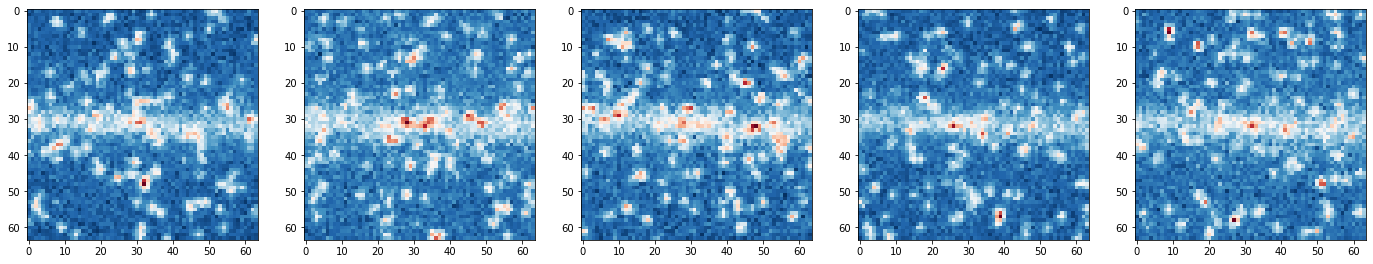

In [70]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy(), cmap=cmap)

In [ ]:
x_samples = torch.zeros(500, 1, 64, 64)
for i in tqdm(range(500)):
    z = torch.randn(size=(1, 1, 64,64))
    x_samples[i, :] = model.flow(z, reverse=True)[0][0]

  0%|          | 0/500 [00:00<?, ?it/s]

In [37]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [47]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:500, 0]])

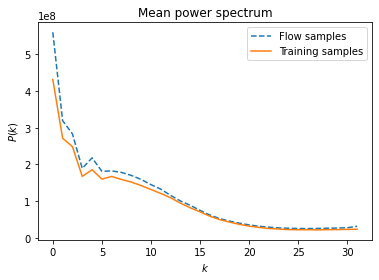

In [48]:
plt.plot(np.nanmean(x_pspec_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0), label="Training samples")

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title("Mean power spectrum")
         
plt.legend()

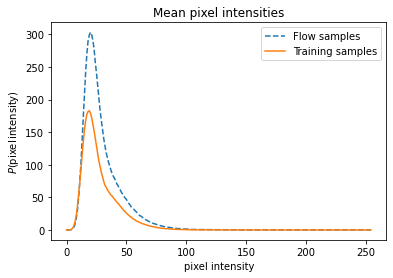

In [49]:
plt.plot(np.nanmean(x_hist_samples, axis=0) * 1.66, label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples")

plt.xlabel("pixel intensity")
plt.ylabel("$P(\mathrm{pixel\,intensity})$")
plt.title("Mean pixel intensities")
         
plt.legend()